In [1]:
!pip install flask flask-ngrok pyngrok spacy -q
!python -m spacy download en_core_web_sm -q
print("✅ All libraries installed!")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 99.4 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
✅ All libraries installed!


In [2]:
# Ngrok gives your Colab a public URL so the API can be accessed from anywhere
# Sign up free at https://ngrok.com and get your auth token
# Paste your token below

from pyngrok import ngrok

NGROK_TOKEN = "3FTd8Xle8HYi1Yh4Zr9ja3pJorY_3mk8Li5F5qptp5mCKQSHU"   # <-- paste your token here
ngrok.set_auth_token(NGROK_TOKEN)
print("✅ Ngrok configured!")


✅ Ngrok configured!


In [3]:
import re
import spacy

nlp = spacy.load("en_core_web_sm")

# ── PII Regex Patterns ──────────────────────────────────────────
PII_PATTERNS = {
    "EMAIL":        (r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}',  "HIGH"),
    "PHONE":        (r'\b(\+?\d{1,3}[\s.\-]?)?\(?\d{3}\)?[\s.\-]?\d{3}[\s.\-]?\d{4}\b', "HIGH"),
    "SSN":          (r'\b\d{3}-\d{2}-\d{4}\b',                             "HIGH"),
    "CREDIT_CARD":  (r'\b(?:\d{4}[\- ]?){3}\d{4}\b',                       "HIGH"),
    "IP_ADDRESS":   (r'\b(?:\d{1,3}\.){3}\d{1,3}\b',                       "MEDIUM"),
    "DATE_OF_BIRTH":(r'\b(0[1-9]|1[0-2])[/\-](0[1-9]|[12]\d|3[01])[/\-](19|20)\d{2}\b', "LOW"),
    "ZIPCODE":      (r'\b\d{5}(?:-\d{4})?\b',                               "LOW"),
}

MASK_MAP = {
    "EMAIL":         "[EMAIL REDACTED]",
    "PHONE":         "[PHONE REDACTED]",
    "SSN":           "[SSN REDACTED]",
    "CREDIT_CARD":   "[CARD REDACTED]",
    "IP_ADDRESS":    "[IP REDACTED]",
    "DATE_OF_BIRTH": "[DOB REDACTED]",
    "ZIPCODE":       "[ZIP REDACTED]",
}

def detect_pii(text):
    """Detect PII using Regex + NER. Returns list of findings."""
    findings = []

    # Regex scan
    for pii_type, (pattern, risk) in PII_PATTERNS.items():
        matches = re.findall(pattern, text)
        if matches:
            findings.append({
                "type":    pii_type,
                "risk":    risk,
                "matches": matches if isinstance(matches[0], str)
                           else [''.join(m) for m in matches],
                "method":  "regex"
            })

    # NER scan
    doc = nlp(text[:500])
    for ent in doc.ents:
        if ent.label_ in ["PERSON", "GPE", "LOC", "ORG"]:
            risk = "HIGH" if ent.label_ == "PERSON" else "MEDIUM"
            findings.append({
                "type":    ent.label_,
                "risk":    risk,
                "matches": [ent.text],
                "method":  "NER"
            })

    return findings

def mask_pii(text):
    """Replace all detected PII in text with masked placeholders."""
    masked = text
    for pii_type, (pattern, _) in PII_PATTERNS.items():
        masked = re.sub(pattern, MASK_MAP[pii_type], masked)
    return masked

def get_risk_level(findings):
    """Determine overall risk level from findings."""
    risks = [f["risk"] for f in findings]
    if "HIGH"   in risks: return "HIGH"
    if "MEDIUM" in risks: return "MEDIUM"
    if "LOW"    in risks: return "LOW"
    return "NONE"

print("✅ PII detection functions ready!")
print("\nTest run:")
sample = "Hi, I am John Smith. Email: john@gmail.com, SSN: 123-45-6789, Phone: 555-123-4567"
findings = detect_pii(sample)
for f in findings:
    print(f"  [{f['risk']}] {f['type']} → {f['matches']} (via {f['method']})")


✅ PII detection functions ready!

Test run:
  [HIGH] EMAIL → ['john@gmail.com'] (via regex)
  [HIGH] PHONE → [''] (via regex)
  [HIGH] SSN → ['123-45-6789'] (via regex)
  [HIGH] PERSON → ['John Smith'] (via NER)
  [MEDIUM] ORG → ['SSN'] (via NER)
  [MEDIUM] ORG → ['Phone'] (via NER)


In [4]:
from flask import Flask, request, jsonify
import datetime

app = Flask(__name__)

# ────────────────────────────────────────────
# ROUTE 1: Home — Check if API is running
# ────────────────────────────────────────────
@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "status":  "running",
        "api":     "PII Detection API",
        "version": "1.0",
        "author":  "Testing Solutions Internship",
        "endpoints": {
            "GET  /":         "API status",
            "POST /detect":   "Detect PII in text",
            "POST /mask":     "Detect + Mask PII in text",
            "POST /analyze":  "Full PII analysis report"
        }
    })

# ────────────────────────────────────────────
# ROUTE 2: /detect — Detect PII only
# ────────────────────────────────────────────
@app.route("/detect", methods=["POST"])
def detect():
    data = request.get_json()
    if not data or "text" not in data:
        return jsonify({"error": "Please send JSON with 'text' field"}), 400

    text     = data["text"]
    findings = detect_pii(text)
    pii_types = list(set(f["type"] for f in findings))

    return jsonify({
        "input_text":  text,
        "pii_found":   pii_types,
        "total_found": len(findings),
        "details":     findings
    })

# ────────────────────────────────────────────
# ROUTE 3: /mask — Detect + Mask PII
# ────────────────────────────────────────────
@app.route("/mask", methods=["POST"])
def mask():
    data = request.get_json()
    if not data or "text" not in data:
        return jsonify({"error": "Please send JSON with 'text' field"}), 400

    text        = data["text"]
    findings    = detect_pii(text)
    masked_text = mask_pii(text)
    pii_types   = list(set(f["type"] for f in findings))

    return jsonify({
        "original_text": text,
        "masked_text":   masked_text,
        "pii_found":     pii_types,
        "total_found":   len(findings)
    })

# ────────────────────────────────────────────
# ROUTE 4: /analyze — Full analysis report
# ────────────────────────────────────────────
@app.route("/analyze", methods=["POST"])
def analyze():
    data = request.get_json()
    if not data or "text" not in data:
        return jsonify({"error": "Please send JSON with 'text' field"}), 400

    text        = data["text"]
    findings    = detect_pii(text)
    masked_text = mask_pii(text)
    risk_level  = get_risk_level(findings)
    pii_types   = list(set(f["type"] for f in findings))

    # Risk advice
    advice_map = {
        "HIGH":   "Immediate action required — contains highly sensitive PII",
        "MEDIUM": "Review recommended — contains moderately sensitive PII",
        "LOW":    "Low risk — contains minor identifiers",
        "NONE":   "No PII detected — text appears safe"
    }

    return jsonify({
        "timestamp":     datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "original_text": text,
        "masked_text":   masked_text,
        "risk_level":    risk_level,
        "advice":        advice_map[risk_level],
        "pii_types":     pii_types,
        "total_pii":     len(findings),
        "details":       findings
    })

print("✅ Flask API routes defined!")
print("   GET  /        → API status")
print("   POST /detect  → Detect PII")
print("   POST /mask    → Detect + Mask PII")
print("   POST /analyze → Full report")


✅ Flask API routes defined!
   GET  /        → API status
   POST /detect  → Detect PII
   POST /mask    → Detect + Mask PII
   POST /analyze → Full report


In [5]:
import threading
from pyngrok import ngrok

# Start Flask in a background thread
def run_flask():
    app.run(port=5000, use_reloader=False)

thread = threading.Thread(target=run_flask)
thread.daemon = True
thread.start()

# Create public URL using ngrok
public_url = ngrok.connect(5000)
print("=" * 55)
print("✅ Flask PII API is LIVE!")
print(f"   Public URL : {public_url}")
print(f"   Home       : {public_url}/")
print(f"   Detect     : {public_url}/detect")
print(f"   Mask       : {public_url}/mask")
print(f"   Analyze    : {public_url}/analyze")
print("=" * 55)
print("Keep this cell running. Use cells below to test the API.")


 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit


✅ Flask PII API is LIVE!
   Public URL : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"
   Home       : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/
   Detect     : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/detect
   Mask       : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/mask
   Analyze    : NgrokTunnel: "https://wriggle-connector-aviation.ngrok-free.dev" -> "http://localhost:5000"/analyze
Keep this cell running. Use cells below to test the API.


In [6]:
import requests

# ── Test 1: Check if API is running ──
print("TEST 1: Home Endpoint (GET /)")
print("-" * 45)
res = requests.get("http://localhost:5000/")
print(res.json())


INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:03] "GET / HTTP/1.1" 200 -


TEST 1: Home Endpoint (GET /)
---------------------------------------------
{'api': 'PII Detection API', 'author': 'Testing Solutions Internship', 'endpoints': {'GET  /': 'API status', 'POST /analyze': 'Full PII analysis report', 'POST /detect': 'Detect PII in text', 'POST /mask': 'Detect + Mask PII in text'}, 'status': 'running', 'version': '1.0'}


In [7]:
# ── Test 2: Detect PII ──
print("TEST 2: Detect Endpoint (POST /detect)")
print("-" * 45)
payload = {"text": "My name is Sarah Connor. My email is sarah@gmail.com and SSN is 234-56-7890"}
res = requests.post("http://localhost:5000/detect", json=payload)
import json
print(json.dumps(res.json(), indent=2))


INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:06] "POST /detect HTTP/1.1" 200 -


TEST 2: Detect Endpoint (POST /detect)
---------------------------------------------
{
  "details": [
    {
      "matches": [
        "sarah@gmail.com"
      ],
      "method": "regex",
      "risk": "HIGH",
      "type": "EMAIL"
    },
    {
      "matches": [
        "234-56-7890"
      ],
      "method": "regex",
      "risk": "HIGH",
      "type": "SSN"
    },
    {
      "matches": [
        "Sarah Connor"
      ],
      "method": "NER",
      "risk": "HIGH",
      "type": "PERSON"
    },
    {
      "matches": [
        "SSN"
      ],
      "method": "NER",
      "risk": "MEDIUM",
      "type": "ORG"
    }
  ],
  "input_text": "My name is Sarah Connor. My email is sarah@gmail.com and SSN is 234-56-7890",
  "pii_found": [
    "PERSON",
    "SSN",
    "EMAIL",
    "ORG"
  ],
  "total_found": 4
}


In [8]:
# ── Test 3: Mask PII ──
print("TEST 3: Mask Endpoint (POST /mask)")
print("-" * 45)
payload = {"text": "Call me at 555-234-5678 or email john.doe@company.com. Card: 4111 1111 1111 1111"}
res = requests.post("http://localhost:5000/mask", json=payload)
print(json.dumps(res.json(), indent=2))


INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:10] "POST /mask HTTP/1.1" 200 -


TEST 3: Mask Endpoint (POST /mask)
---------------------------------------------
{
  "masked_text": "Call me at [PHONE REDACTED] or email [EMAIL REDACTED]. Card: [CARD REDACTED]",
  "original_text": "Call me at 555-234-5678 or email john.doe@company.com. Card: 4111 1111 1111 1111",
  "pii_found": [
    "EMAIL",
    "PHONE",
    "CREDIT_CARD"
  ],
  "total_found": 3
}


In [9]:
# ── Test 4: Full Analysis ──
print("TEST 4: Full Analysis (POST /analyze)")
print("-" * 45)
payload = {"text": "Patient John Smith DOB 03/15/1990, SSN 123-45-6789, lives at IP 192.168.1.1, email jsmith@hospital.com"}
res = requests.post("http://localhost:5000/analyze", json=payload)
print(json.dumps(res.json(), indent=2))


INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:13] "POST /analyze HTTP/1.1" 200 -


TEST 4: Full Analysis (POST /analyze)
---------------------------------------------
{
  "advice": "Immediate action required \u2014 contains highly sensitive PII",
  "details": [
    {
      "matches": [
        "jsmith@hospital.com"
      ],
      "method": "regex",
      "risk": "HIGH",
      "type": "EMAIL"
    },
    {
      "matches": [
        "123-45-6789"
      ],
      "method": "regex",
      "risk": "HIGH",
      "type": "SSN"
    },
    {
      "matches": [
        "192.168.1.1"
      ],
      "method": "regex",
      "risk": "MEDIUM",
      "type": "IP_ADDRESS"
    },
    {
      "matches": [
        "031519"
      ],
      "method": "regex",
      "risk": "LOW",
      "type": "DATE_OF_BIRTH"
    },
    {
      "matches": [
        "John Smith"
      ],
      "method": "NER",
      "risk": "HIGH",
      "type": "PERSON"
    },
    {
      "matches": [
        "SSN"
      ],
      "method": "NER",
      "risk": "MEDIUM",
      "type": "ORG"
    }
  ],
  "masked_text": "Pati

In [10]:
import pandas as pd

test_texts = [
    "Hello, how are you today?",
    "My email is alice@example.com",
    "SSN: 987-65-4321 and phone 800-555-1234",
    "IP address is 10.0.0.1, zip code 90210",
    "John Doe, card 4111-1111-1111-1111, email john@test.com, SSN 111-22-3333",
    "The meeting is scheduled for tomorrow at 3pm",
    "Contact: jane@company.org, Phone: 415-555-9876, DOB: 06/21/1985",
]

results = []
for text in test_texts:
    res = requests.post("http://localhost:5000/analyze", json={"text": text}).json()
    results.append({
        "Input Text":   text[:55] + "..." if len(text) > 55 else text,
        "Risk Level":   res["risk_level"],
        "PII Types":    ", ".join(res["pii_types"]) if res["pii_types"] else "None",
        "Total PII":    res["total_pii"],
        "Masked Text":  res["masked_text"][:55] + "..." if len(res["masked_text"]) > 55 else res["masked_text"]
    })

df_results = pd.DataFrame(results)
print("API TEST RESULTS")
print("=" * 80)
print(df_results.to_string(index=False))


INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:17] "POST /analyze HTTP/1.1" 200 -


API TEST RESULTS
                                                Input Text Risk Level                            PII Types  Total PII                                                Masked Text
                                 Hello, how are you today?       NONE                                 None          0                                  Hello, how are you today?
                             My email is alice@example.com       HIGH                                EMAIL          1                               My email is [EMAIL REDACTED]
                   SSN: 987-65-4321 and phone 800-555-1234       HIGH                      ORG, SSN, PHONE          3             SSN: [SSN REDACTED] and phone [PHONE REDACTED]
                    IP address is 10.0.0.1, zip code 90210     MEDIUM             IP_ADDRESS, ZIPCODE, ORG          3       IP address is [IP REDACTED], zip code [ZIP REDACTED]
John Doe, card 4111-1111-1111-1111, email john@test.com...       HIGH PERSON, SSN, ORG, EMAIL, CRE

INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [22/Jun/2026 04:37:21] "POST /analyze HTTP/1.1" 200 -


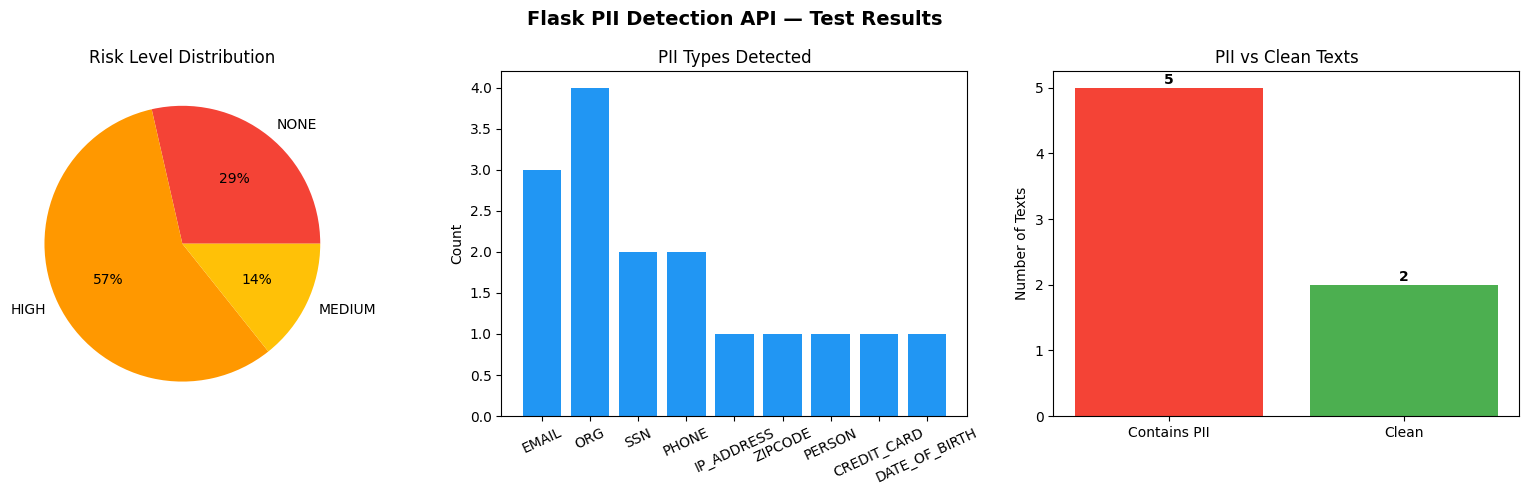

✅ Chart saved!


In [11]:
import matplotlib.pyplot as plt
from collections import Counter

# Run tests and collect data
all_risks, all_types = [], []
for text in test_texts:
    res = requests.post("http://localhost:5000/analyze", json={"text": text}).json()
    all_risks.append(res["risk_level"])
    all_types.extend(res["pii_types"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Flask PII Detection API — Test Results", fontsize=14, fontweight='bold')

# 1. Risk level pie
risk_counts = Counter(all_risks)
axes[0].pie(risk_counts.values(), labels=risk_counts.keys(), autopct='%1.0f%%',
            colors=['#F44336','#FF9800','#FFC107','#4CAF50'])
axes[0].set_title('Risk Level Distribution')

# 2. PII types bar
type_counts = Counter(all_types)
if type_counts:
    axes[1].bar(list(type_counts.keys()), list(type_counts.values()), color='#2196F3')
    axes[1].set_title('PII Types Detected')
    axes[1].set_ylabel('Count')
    axes[1].tick_params(axis='x', rotation=25)
else:
    axes[1].text(0.5, 0.5, 'No PII', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('PII Types Detected')

# 3. Clean vs PII texts
pii_texts   = sum(1 for r in all_risks if r != 'NONE')
clean_texts = len(all_risks) - pii_texts
axes[2].bar(['Contains PII', 'Clean'], [pii_texts, clean_texts], color=['#F44336','#4CAF50'])
axes[2].set_title('PII vs Clean Texts')
axes[2].set_ylabel('Number of Texts')
for i, v in enumerate([pii_texts, clean_texts]):
    axes[2].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig("flask_api_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Chart saved!")



### Flow:
```
User sends text (POST request)
        ↓
Flask API receives it
        ↓
Regex + spaCy NER scans for PII
        ↓
Risk level assigned (HIGH/MEDIUM/LOW/NONE)
        ↓
Masked text generated
        ↓
JSON response returned to user
```
